In [8]:
import pandas as pd
import numpy as np
pd.set_option('display.max_columns', 120)
pd.set_option('display.max_colwidth', 5000)
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
plt.rcParams['figure.figsize'] = (12,8)

In [10]:
# skip row 1 so pandas can parse the data properly.
loans_2007 = pd.read_csv('d:/ipython/lending_club_loans.csv', skiprows=1, low_memory=False)
half_count = len(loans_2007) / 2
loans_2007 = loans_2007.dropna(thresh=half_count,axis=1) # Drop any column with more than 50% missing values

In [12]:
loans_2007 = loans_2007.drop(['url','desc'],axis=1) # These columns are not useful for our purposes

In [14]:
loans_2007.head(3)

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,fico_range_low,fico_range_high,inq_last_6mths,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,last_credit_pull_d,last_fico_range_high,last_fico_range_low,collections_12_mths_ex_med,policy_code,application_type,acc_now_delinq,chargeoff_within_12_mths,delinq_amnt,pub_rec_bankruptcies,tax_liens
0,1077501,1296599.0,5000.0,5000.0,4975.0,36 months,10.65%,162.87,B,B2,NaN,10+ years,RENT,24000.0,Verified,Dec-2011,Fully Paid,n,credit_card,Computer,860xx,AZ,27.65,0.0,Jan-1985,735.0,739.0,1.0,3.0,0.0,13648.0,83.7%,9.0,f,0.0,0.0,5863.155187,5833.84,5000.00,863.16,0.0,0.00,0.00,Jan-2015,171.62,Sep-2016,744.0,740.0,0.0,1.0,INDIVIDUAL,0.0,0.0,0.0,0.0,0.0
1,1077430,1314167.0,2500.0,2500.0,2500.0,60 months,15.27%,59.83,C,C4,Ryder,< 1 year,RENT,30000.0,Source Verified,Dec-2011,Charged Off,n,car,bike,309xx,GA,1.00,0.0,Apr-1999,740.0,744.0,5.0,3.0,0.0,1687.0,9.4%,4.0,f,0.0,0.0,1008.710000,1008.71,456.46,435.17,0.0,117.08,1.11,Apr-2013,119.66,Sep-2016,499.0,0.0,0.0,1.0,INDIVIDUAL,0.0,0.0,0.0,0.0,0.0
2,1077175,1313524.0,2400.0,2400.0,2400.0,36 months,15.96%,84.33,C,C5,NaN,10+ years,RENT,12252.0,Not Verified,Dec-2011,Fully Paid,n,small_business,real estate business,606xx,IL,8.72,0.0,Nov-2001,735.0,739.0,2.0,2.0,0.0,2956.0,98.5%,10.0,f,0.0,0.0,3005.666844,3005.67,2400.00,605.67,0.0,0.00,0.00,Jun-2014,649.91,Sep-2016,719.0,715.0,0.0,1.0,INDIVIDUAL,0.0,0.0,0.0,0.0,0.0


In [16]:
loans_2007.shape

(42538, 56)

In [18]:
data_dictionary = pd.read_csv('d:/ipython/LCDataDictionary.csv') # Loading in the data dictionary
print(data_dictionary.shape[0])
print(data_dictionary.columns.tolist())

117
['LoanStatNew', 'Description']


In [20]:
data_dictionary.head()
data_dictionary = data_dictionary.rename(columns={'LoanStatNew': 'name', 'Description': 'description'})

In [22]:
loans_2007_dtypes = pd.DataFrame(loans_2007.dtypes,columns=['dtypes'])
loans_2007_dtypes = loans_2007_dtypes.reset_index()
loans_2007_dtypes['name'] = loans_2007_dtypes['index']
loans_2007_dtypes = loans_2007_dtypes[['name','dtypes']]
loans_2007_dtypes['first value'] = loans_2007.loc[0].values
preview = loans_2007_dtypes.merge(data_dictionary, on='name',how='left')

In [24]:
preview[:]

,name,dtypes,first value,description
0,id,object,1077501,A unique LC assigned ID for the loan listing.
1,member_id,float64,1296599.0,A unique LC assigned Id for the borrower member.
2,loan_amnt,float64,5000.0,"The listed amount of the loan applied for by the borrower. If at some point in time, the credit department reduces the loan amount, then it will be reflected in this value."
3,funded_amnt,float64,5000.0,The total amount committed to that loan at that point in time.
4,funded_amnt_inv,float64,4975.0,The total amount committed by investors for that loan at that point in time.
5,term,object,36 months,The number of payments on the loan. Values are in months and can be either 36 or 60.
6,int_rate,object,10.65%,Interest Rate on the loan
7,installment,float64,162.87,The monthly payment owed by the borrower if the loan originates.
8,grade,object,B,LC assigned loan grade
9,sub_grade,object,B2,LC assigned loan subgrade


In [26]:
drop_list = ['id','member_id','funded_amnt','funded_amnt_inv','int_rate','sub_grade','emp_title','issue_d']
loans_2007 = loans_2007.drop(drop_list,axis=1)

In [28]:
drop_cols = [ 'zip_code','out_prncp','out_prncp_inv','total_pymnt','total_pymnt_inv']
loans_2007 = loans_2007.drop(drop_cols, axis=1)

In [30]:
drop_cols = ['total_rec_prncp','total_rec_int','total_rec_late_fee','recoveries','collection_recovery_fee',
             'last_pymnt_d','last_pymnt_amnt']
loans_2007 = loans_2007.drop(drop_cols, axis=1)

In [32]:
print(loans_2007['fico_range_low'].unique())
print(loans_2007['fico_range_high'].unique())

[735. 740. 690. 695. 730. 660. 675. 725. 710. 705. 720. 665. 670. 760.
 685. 755. 680. 700. 790. 750. 715. 765. 745. 770. 780. 775. 795. 810.
 800. 815. 785. 805. 825. 820. 630. 625.  nan 650. 655. 645. 640. 635.
 610. 620. 615.]
[739. 744. 694. 699. 734. 664. 679. 729. 714. 709. 724. 669. 674. 764.
 689. 759. 684. 704. 794. 754. 719. 769. 749. 774. 784. 779. 799. 814.
 804. 819. 789. 809. 829. 824. 634. 629.  nan 654. 659. 649. 644. 639.
 614. 624. 619.]


42538
42535


<Axes: ylabel='Frequency'>

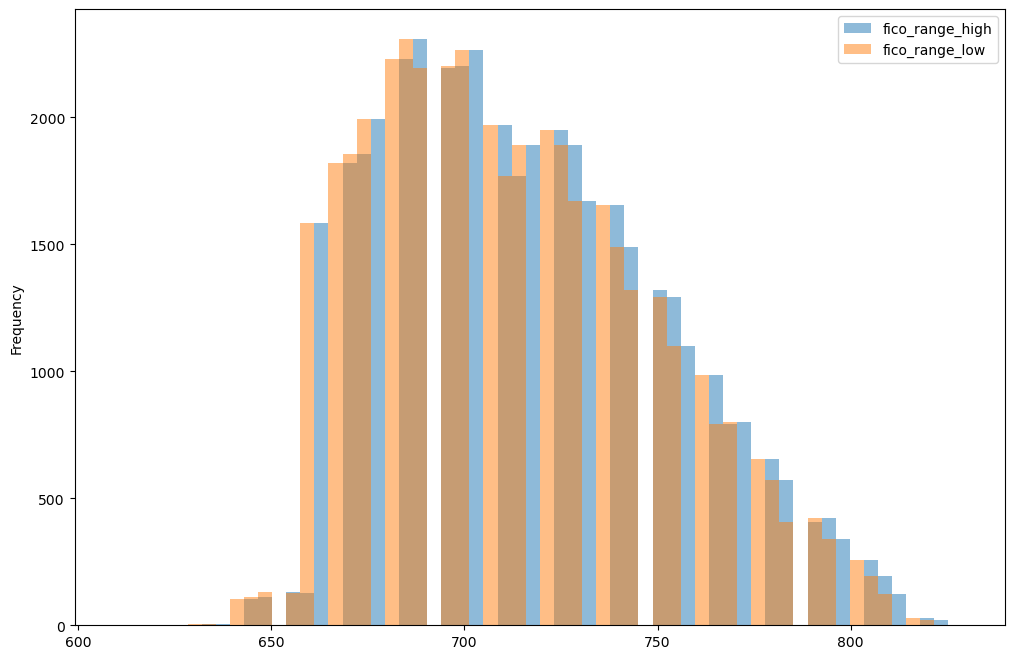

In [34]:
fico_columns = ['fico_range_high','fico_range_low']
print(loans_2007.shape[0])
loans_2007.dropna(subset=fico_columns,inplace=True)
print(loans_2007.shape[0])
loans_2007[fico_columns].plot.hist(alpha=0.5,bins=60)

In [36]:
loans_2007['fico_average'] = (loans_2007['fico_range_high'] + loans_2007['fico_range_low']) / 2

In [38]:
cols = ['fico_range_low','fico_range_high','fico_average']
loans_2007[cols].head()

,fico_range_low,fico_range_high,fico_average
0,735.0,739.0,737.0
1,740.0,744.0,742.0
2,735.0,739.0,737.0
3,690.0,694.0,692.0
4,695.0,699.0,697.0


In [40]:
drop_cols = ['fico_range_low','fico_range_high','last_fico_range_low', 'last_fico_range_high']
loans_2007 = loans_2007.drop(drop_cols, axis=1)
loans_2007.shape

(42535, 33)

In [42]:
preview[preview.name == 'loan_status']

,name,dtypes,first value,description
16,loan_status,object,Fully Paid,Current status of the loan


In [44]:
loans_2007["loan_status"].value_counts()

loan_status
Fully Paid                                             33586
Charged Off                                             5653
Does not meet the credit policy. Status:Fully Paid      1988
Does not meet the credit policy. Status:Charged Off      761
Current                                                  513
In Grace Period                                           16
Late (31-120 days)                                        12
Late (16-30 days)                                          5
Default                                                    1
Name: count, dtype: int64

In [46]:
meaning = [
"Loan has been fully paid off.",
"Loan for which there is no longer a reasonable expectation of further payments.",
"While the loan was paid off, the loan application today would no longer meet the credit policy and wouldn't be approved on to the marketplace.",
"While the loan was charged off, the loan application today would no longer meet the credit policy and wouldn't be approved on to the marketplace.",
"Loan is up to date on current payments.",
"The loan is past due but still in the grace period of 15 days.",
"Loan hasn't been paid in 31 to 120 days (late on the current payment).",
"Loan hasn't been paid in 16 to 30 days (late on the current payment).",
"Loan is defaulted on and no payment has been made for more than 121 days."]
status, count = loans_2007["loan_status"].value_counts().index, loans_2007["loan_status"].value_counts().values
loan_statuses_explanation = pd.DataFrame(
    {'Loan Status': status,'Count': count,'Meaning': meaning})[['Loan Status','Count','Meaning']]
loan_statuses_explanation

,Loan Status,Count,Meaning
0,Fully Paid,33586,Loan has been fully paid off.
1,Charged Off,5653,Loan for which there is no longer a reasonable expectation of further payments.
2,Does not meet the credit policy. Status:Fully Paid,1988,"While the loan was paid off, the loan application today would no longer meet the credit policy and wouldn't be approved on to the marketplace."
3,Does not meet the credit policy. Status:Charged Off,761,"While the loan was charged off, the loan application today would no longer meet the credit policy and wouldn't be approved on to the marketplace."
4,Current,513,Loan is up to date on current payments.
5,In Grace Period,16,The loan is past due but still in the grace period of 15 days.
6,Late (31-120 days),12,Loan hasn't been paid in 31 to 120 days (late on the current payment).
7,Late (16-30 days),5,Loan hasn't been paid in 16 to 30 days (late on the current payment).
8,Default,1,Loan is defaulted on and no payment has been made for more than 121 days.


In [48]:
loans_2007 = loans_2007[(loans_2007["loan_status"] == "Fully Paid") |
    (loans_2007["loan_status"] == "Charged Off")]
mapping_dictionary = {"loan_status":{ "Fully Paid": 1, "Charged Off": 0}}
loans_2007 = loans_2007.replace(mapping_dictionary)

C:\Users\USER2018\AppData\Local\Temp\ipykernel_12728\4238238132.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  loans_2007 = loans_2007.replace(mapping_dictionary)


In [50]:
loans_2007.to_csv("d:/ipython/filtered_loans_2007.csv",index=False)

In [51]:
filtered_loans = pd.read_csv('d:/ipython/filtered_loans_2007.csv')
print(filtered_loans.shape)
filtered_loans.head()

(39239, 33)


,loan_amnt,term,installment,grade,emp_length,home_ownership,annual_inc,verification_status,loan_status,pymnt_plan,purpose,title,addr_state,dti,delinq_2yrs,earliest_cr_line,inq_last_6mths,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,last_credit_pull_d,collections_12_mths_ex_med,policy_code,application_type,acc_now_delinq,chargeoff_within_12_mths,delinq_amnt,pub_rec_bankruptcies,tax_liens,fico_average
0,5000.0,36 months,162.87,B,10+ years,RENT,24000.0,Verified,1,n,credit_card,Computer,AZ,27.65,0.0,Jan-1985,1.0,3.0,0.0,13648.0,83.7%,9.0,f,Sep-2016,0.0,1.0,INDIVIDUAL,0.0,0.0,0.0,0.0,0.0,737.0
1,2500.0,60 months,59.83,C,< 1 year,RENT,30000.0,Source Verified,0,n,car,bike,GA,1.00,0.0,Apr-1999,5.0,3.0,0.0,1687.0,9.4%,4.0,f,Sep-2016,0.0,1.0,INDIVIDUAL,0.0,0.0,0.0,0.0,0.0,742.0
2,2400.0,36 months,84.33,C,10+ years,RENT,12252.0,Not Verified,1,n,small_business,real estate business,IL,8.72,0.0,Nov-2001,2.0,2.0,0.0,2956.0,98.5%,10.0,f,Sep-2016,0.0,1.0,INDIVIDUAL,0.0,0.0,0.0,0.0,0.0,737.0
3,10000.0,36 months,339.31,C,10+ years,RENT,49200.0,Source Verified,1,n,other,personel,CA,20.00,0.0,Feb-1996,1.0,10.0,0.0,5598.0,21%,37.0,f,Apr-2016,0.0,1.0,INDIVIDUAL,0.0,0.0,0.0,0.0,0.0,692.0
4,5000.0,36 months,156.46,A,3 years,RENT,36000.0,Source Verified,1,n,wedding,My wedding loan I promise to pay back,AZ,11.20,0.0,Nov-2004,3.0,9.0,0.0,7963.0,28.3%,12.0,f,Jan-2016,0.0,1.0,INDIVIDUAL,0.0,0.0,0.0,0.0,0.0,732.0


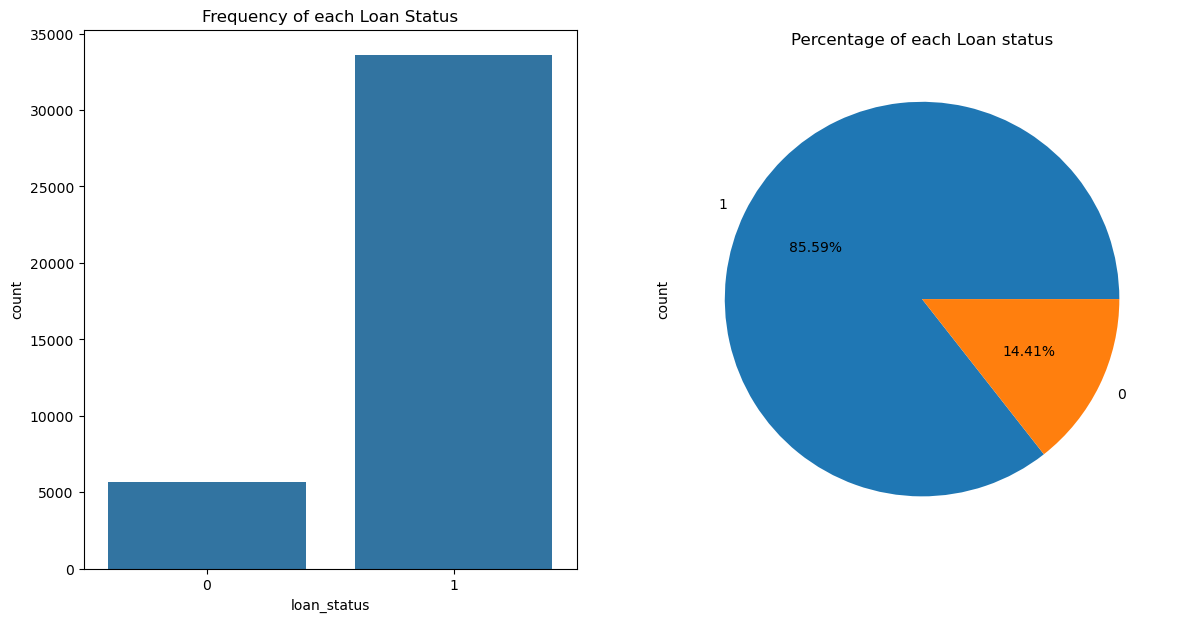

In [54]:
fig, axs = plt.subplots(1,2,figsize=(14,7))
sns.countplot(x='loan_status',data=filtered_loans,ax=axs[0])
axs[0].set_title("Frequency of each Loan Status")
filtered_loans.loan_status.value_counts().plot(x=None,y=None, kind='pie', ax=axs[1],autopct='%1.2f%%')
axs[1].set_title("Percentage of each Loan status")
plt.show()

In [56]:
loans_2007 = loans_2007.loc[:,loans_2007.apply(pd.Series.nunique) != 1]

In [58]:
for col in loans_2007.columns:
    if (len(loans_2007[col].unique()) < 4):
        print(loans_2007[col].value_counts())
    print()


term
36 months    29096
60 months    10143
Name: count, dtype: int64






verification_status
Not Verified       16845
Verified           12526
Source Verified     9868
Name: count, dtype: int64

loan_status
1    33586
0     5653
Name: count, dtype: int64

pymnt_plan
n    39238
y        1
Name: count, dtype: int64


















In [60]:
print(loans_2007.shape[1])
loans_2007 = loans_2007.drop('pymnt_plan', axis=1)
print("We've been able to reduce the features to => {}".format(loans_2007.shape[1]))

25
We've been able to reduce the features to => 24


In [62]:
null_counts = filtered_loans.isnull().sum()
print("Number of null values in each column:\n{}".format(null_counts))

Number of null values in each column:
loan_amnt                        0
term                             0
installment                      0
grade                            0
emp_length                    1057
home_ownership                   0
annual_inc                       0
verification_status              0
loan_status                      0
pymnt_plan                       0
purpose                          0
title                           11
addr_state                       0
dti                              0
delinq_2yrs                      0
earliest_cr_line                 0
inq_last_6mths                   0
open_acc                         0
pub_rec                          0
revol_bal                        0
revol_util                      50
total_acc                        0
initial_list_status              0
last_credit_pull_d               2
collections_12_mths_ex_med      56
policy_code                      0
application_type                 0
acc_now_delinq   

In [64]:
filtered_loans = filtered_loans.drop("pub_rec_bankruptcies",axis=1)
filtered_loans = filtered_loans.dropna()

In [66]:
print("Data types and their frequency\n{}".format(filtered_loans.dtypes.value_counts()))

Data types and their frequency
float64    17
object     14
int64       1
Name: count, dtype: int64


In [68]:
object_columns_df = filtered_loans.select_dtypes(include=['object'])
print(object_columns_df.iloc[0])

term                     36 months
grade                            B
emp_length               10+ years
home_ownership                RENT
verification_status       Verified
pymnt_plan                       n
purpose                credit_card
title                     Computer
addr_state                      AZ
earliest_cr_line          Jan-1985
revol_util                   83.7%
initial_list_status              f
last_credit_pull_d        Sep-2016
application_type        INDIVIDUAL
Name: 0, dtype: object


In [70]:
filtered_loans['revol_util'] = filtered_loans['revol_util'].str.rstrip('%').astype('float')

In [72]:
cols = ['home_ownership', 'grade','verification_status', 'emp_length', 'term', 'addr_state']
for name in cols:
    print(name,':')
    print(object_columns_df[name].value_counts(),'\n')

home_ownership :
home_ownership
RENT        18251
MORTGAGE    16917
OWN          2802
OTHER          96
NONE            1
Name: count, dtype: int64 

grade :
grade
B    11531
A     9654
C     7789
D     5082
E     2712
F      991
G      308
Name: count, dtype: int64 

verification_status :
verification_status
Not Verified       16335
Verified           12070
Source Verified     9662
Name: count, dtype: int64 

emp_length :
emp_length
10+ years    8712
< 1 year     4524
2 years      4337
3 years      4046
4 years      3381
5 years      3241
1 year       3197
6 years      2196
7 years      1736
8 years      1455
9 years      1242
Name: count, dtype: int64 

term :
term
36 months    28178
60 months     9889
Name: count, dtype: int64 

addr_state :
addr_state
CA    6832
NY    3650
FL    2736
TX    2639
NJ    1800
IL    1476
PA    1460
VA    1356
GA    1336
MA    1280
OH    1167
MD    1018
AZ     818
WA     796
CO     752
NC     746
CT     718
MI     684
MO     653
MN     586
NV     473
SC 

In [74]:
for name in ['purpose','title']:
    print("Unique Values in column: {}\n".format(name))
print(filtered_loans[name].value_counts(),'\n')

Unique Values in column: purpose

Unique Values in column: title

title
Debt Consolidation                       2102
Debt Consolidation Loan                  1635
Personal Loan                             632
Consolidation                             494
debt consolidation                        476
                                         ... 
 APRILIA TUONO 1000R                        1
Business Development Loan                   1
Found a great sailboat deal!                1
utang                                       1
Engineer seeks Environmental Training       1
Name: count, Length: 18976, dtype: int64 



In [76]:
drop_cols = ['last_credit_pull_d','addr_state','title','earliest_cr_line']
filtered_loans = filtered_loans.drop(drop_cols,axis=1)

In [78]:
mapping_dict = {
"emp_length": {
"10+ years": 10,
"9 years": 9,
"8 years": 8,
"7 years": 7,
"6 years": 6,
"5 years": 5,
"4 years": 4,
"3 years": 3,
"2 years": 2,
"1 year": 1,
"< 1 year": 0,
"n/a": 0
},
"grade":{
"A": 1,
"B": 2,
"C": 3,
"D": 4,
"E": 5,
"F": 6,
"G": 7
}
}
filtered_loans = filtered_loans.replace(mapping_dict)
filtered_loans[['emp_length','grade']].head()

C:\Users\USER2018\AppData\Local\Temp\ipykernel_12728\2070521355.py:26: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  filtered_loans = filtered_loans.replace(mapping_dict)


,emp_length,grade
0,10,2
1,0,3
2,10,3
3,10,3
4,3,1


In [80]:
nominal_columns = ["home_ownership", "verification_status", "purpose", "term"]
dummy_df = pd.get_dummies(filtered_loans[nominal_columns])
filtered_loans = pd.concat([filtered_loans, dummy_df], axis=1)
filtered_loans = filtered_loans.drop(nominal_columns, axis=1)

In [82]:
filtered_loans.head()

,loan_amnt,installment,grade,emp_length,annual_inc,loan_status,pymnt_plan,dti,delinq_2yrs,inq_last_6mths,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,collections_12_mths_ex_med,policy_code,application_type,acc_now_delinq,chargeoff_within_12_mths,delinq_amnt,tax_liens,fico_average,home_ownership_MORTGAGE,home_ownership_NONE,home_ownership_OTHER,home_ownership_OWN,home_ownership_RENT,verification_status_Not Verified,verification_status_Source Verified,verification_status_Verified,purpose_car,purpose_credit_card,purpose_debt_consolidation,purpose_educational,purpose_home_improvement,purpose_house,purpose_major_purchase,purpose_medical,purpose_moving,purpose_other,purpose_renewable_energy,purpose_small_business,purpose_vacation,purpose_wedding,term_ 36 months,term_ 60 months
0,5000.0,162.87,2,10,24000.0,1,n,27.65,0.0,1.0,3.0,0.0,13648.0,83.7,9.0,f,0.0,1.0,INDIVIDUAL,0.0,0.0,0.0,0.0,737.0,False,False,False,False,True,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False
1,2500.0,59.83,3,0,30000.0,0,n,1.00,0.0,5.0,3.0,0.0,1687.0,9.4,4.0,f,0.0,1.0,INDIVIDUAL,0.0,0.0,0.0,0.0,742.0,False,False,False,False,True,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True
2,2400.0,84.33,3,10,12252.0,1,n,8.72,0.0,2.0,2.0,0.0,2956.0,98.5,10.0,f,0.0,1.0,INDIVIDUAL,0.0,0.0,0.0,0.0,737.0,False,False,False,False,True,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False
3,10000.0,339.31,3,10,49200.0,1,n,20.00,0.0,1.0,10.0,0.0,5598.0,21.0,37.0,f,0.0,1.0,INDIVIDUAL,0.0,0.0,0.0,0.0,692.0,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False
4,5000.0,156.46,1,3,36000.0,1,n,11.20,0.0,3.0,9.0,0.0,7963.0,28.3,12.0,f,0.0,1.0,INDIVIDUAL,0.0,0.0,0.0,0.0,732.0,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,True,False


In [84]:
filtered_loans.info()

<class 'pandas.core.frame.DataFrame'>
Index: 38067 entries, 0 to 39187
Data columns (total 48 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   loan_amnt                            38067 non-null  float64
 1   installment                          38067 non-null  float64
 2   grade                                38067 non-null  int64  
 3   emp_length                           38067 non-null  int64  
 4   annual_inc                           38067 non-null  float64
 5   loan_status                          38067 non-null  int64  
 6   pymnt_plan                           38067 non-null  object 
 7   dti                                  38067 non-null  float64
 8   delinq_2yrs                          38067 non-null  float64
 9   inq_last_6mths                       38067 non-null  float64
 10  open_acc                             38067 non-null  float64
 11  pub_rec                          

In [86]:
filtered_loans.to_csv("d:/ipython/cleaned_loans_2007.csv",index=False)

In [88]:
# cleaned_loans_2007 seperated to lending_club_loans_train.xlsx(at 30000) and lending_club_loans_test.xlsx(after 30000)

In [90]:
# import packages
import warnings
warnings.filterwarnings('ignore')

#import pandas as pd
#import numpy as np

#import seaborn as sns
#import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import precision_recall_curve, auc, average_precision_score

In [92]:
train = pd.read_excel('d:/ipython/lending_club_loans_train.xlsx')

In [93]:
test = pd.read_excel('d:/ipython/lending_club_loans_test.xlsx')

In [94]:
# 1 = good, 0 = default

# give column names
cols = ['home_ownership_MORTGAGE', 'annual_inc', 'dti', 'fico_average', 'loan_status']

In [95]:
for c in cols:    
    print(train[c].value_counts())   # 打印每个object类型特征的特征值及个数    
    print("================================")
    print(test[c].value_counts())   # 打印每个object类型特征的特征值及个数    
    print("================================")

home_ownership_MORTGAGE
0    16168
1    13831
Name: count, dtype: int64
home_ownership_MORTGAGE
0    5011
1    3114
Name: count, dtype: int64
annual_inc
60000.0    1172
50000.0     798
40000.0     659
65000.0     650
75000.0     630
           ... 
91980.0       1
47110.0       1
66984.0       1
50300.0       1
85680.0       1
Name: count, Length: 4070, dtype: int64
annual_inc
60000.00     284
50000.00     216
40000.00     191
45000.00     185
30000.00     182
            ... 
63324.00       1
77078.47       1
47928.00       1
118320.00      1
27376.00       1
Name: count, Length: 1774, dtype: int64
dti
0.00     97
12.00    34
18.00    34
13.20    31
16.80    30
         ..
26.03     1
28.66     1
26.52     1
29.09     1
1.94      1
Name: count, Length: 2849, dtype: int64
dti
0.00     69
6.00     13
13.28    13
13.16    12
9.80     12
         ..
5.60      1
23.51     1
18.63     1
2.22      1
6.07      1
Name: count, Length: 2365, dtype: int64
fico_average
702    1632
687    1576
697 

In [99]:
# remove target column to create feature only dataset
X_train = train.drop('loan_status', axis=1)
X_test = test.drop('loan_status', axis=1)

# store target column
y_train = train['loan_status']
y_test = test['loan_status']

print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)
X_train.columns

(29999, 38) (29999,) (8125, 38) (8125,)


Index(['loan_amnt', 'installment', 'grade', 'emp_length', 'annual_inc', 'dti',
       'delinq_2yrs', 'inq_last_6mths', 'open_acc', 'pub_rec', 'revol_bal',
       'revol_util', 'total_acc', 'fico_average', 'home_ownership_MORTGAGE',
       'home_ownership_NONE', 'home_ownership_OTHER', 'home_ownership_OWN',
       'home_ownership_RENT', 'verification_status_Not Verified',
       'verification_status_Source Verified', 'verification_status_Verified',
       'purpose_car', 'purpose_credit_card', 'purpose_debt_consolidation',
       'purpose_educational', 'purpose_home_improvement', 'purpose_house',
       'purpose_major_purchase', 'purpose_medical', 'purpose_moving',
       'purpose_other', 'purpose_renewable_energy', 'purpose_small_business',
       'purpose_vacation', 'purpose_wedding', 'term_ 36 months',
       'term_ 60 months'],
      dtype='object')

In [101]:
majority_class = y_train.mode()[0]        # predict fully paid only
prediction = np.full(shape=y_train.shape, fill_value=majority_class)
accuracy_score(y_train, prediction)

0.8548284942831428

In [103]:
freq = y_train.value_counts()           # count frequency of different classes in loan status
freq/sum(freq)*100                      # get percentage of above

loan_status
1    85.482849
0    14.517151
Name: count, dtype: float64

In [121]:
# lgstc_reg =  LogisticRegression(penalty="none", solver='newton-cg')     # create an instance of logistic regression
# lgstc_reg =  LogisticRegression(penalty="l1", solver='liblinear')
lgstc_reg =  LogisticRegression(penalty="l2", solver='newton-cg')
lgstc_reg.fit(X_train, y_train)                 # fit training data on logistic regression 

print(lgstc_reg.intercept_, lgstc_reg.coef_)    # get the coefficients of each features

[-0.94500692] [[-1.49946187e-05  1.59753622e-04 -1.07326901e-01 -1.71498520e-02
   7.38733490e-06  1.02564204e-03 -1.83897217e-02 -1.48252097e-01
  -7.90718592e-03 -3.07753916e-01 -2.37440847e-06 -5.23686241e-03
   2.30227785e-03  5.58008796e-03 -1.42252068e-01  0.00000000e+00
  -1.75524061e-01 -2.12063461e-01 -2.51600790e-01 -2.20972112e-01
  -2.89198849e-01 -2.71269418e-01  3.05518812e-01  3.48709697e-01
   5.50831038e-02 -3.09628527e-01  1.42783243e-01 -6.57885769e-02
   2.31033834e-01 -8.19940797e-02 -1.74597913e-01 -1.82474197e-01
  -4.70288108e-01 -7.24850798e-01 -1.98058359e-01  3.43111491e-01
   4.04120395e-03 -7.85481583e-01]]


In [123]:
y_pred = lgstc_reg.predict(X_test)                           # predict default loans based on test data set

acc = accuracy_score(y_test, y_pred)                         # check the accuracy of the model

print('accuracy of logistic regression model=%.3f' % (acc))

accuracy of logistic regression model=0.870


---------------------------------------

THRESHOLD: 0.75 
accuracy: 0.8621538461538462




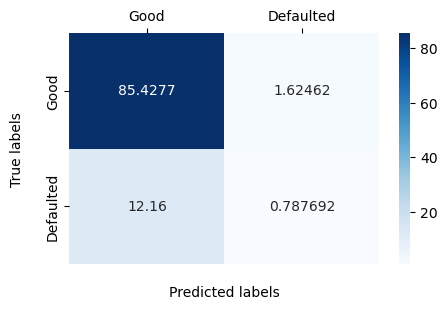

---------------------------------------

THRESHOLD: 0.8 
accuracy: 0.8392615384615385




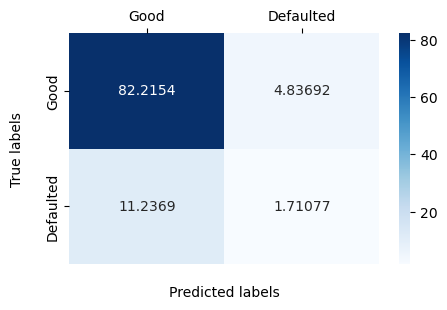

---------------------------------------

THRESHOLD: 0.85 
accuracy: 0.7549538461538462




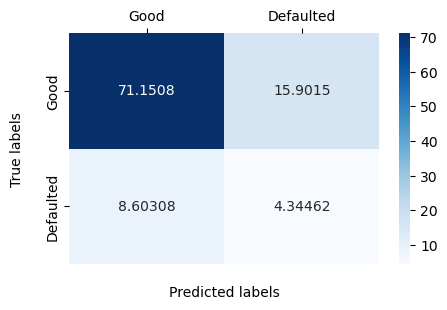

In [125]:
THRESHOLD = [.75, .80, .85]

# to store results
results = pd.DataFrame(columns=["THRESHOLD", "accuracy", "recall", "tnr", "fpr", "precision", "f1_score"]) 
results['THRESHOLD'] = THRESHOLD                                                              # threshold column
             
j = 0                                                                                                      
for i in THRESHOLD:                                                                           # iterate over each threshold    
    
    
    lgstc_reg.fit(X_train, y_train)                                                           # fit data to model
    preds = np.where(lgstc_reg.predict_proba(X_test)[:,1] > i, 1, 0)                          # if prob > threshold, predict 1
    
    cm = (confusion_matrix(y_test, preds,labels=[1, 0], sample_weight=None) / 8125 )*100      # confusion matrix (in percentage)
    TP = cm[0][0]                                                                             # True Positives
    FN = cm[0][1]                                                                             # False Positives
    FP = cm[1][0]                                                                             # True Negatives
    TN = cm[1][1]                                                                             # False Negatives
        
    results.iloc[j,1] = accuracy_score(y_test, preds) 
    results.iloc[j,2] = recall_score(y_test, preds)
    results.iloc[j,3] = TN/(FP+TN)                                                            # True negative rate
    results.iloc[j,4] = FP/(FP+TN)                                                            # False positive rate
    results.iloc[j,5] = precision_score(y_test, preds)
    results.iloc[j,6] = f1_score(y_test, preds)
    
    print( '---------------------------------------\n' )
    print('THRESHOLD:', i, '\naccuracy:', results.iloc[j,1])
    print( '\n' )
    
    plt.figure(figsize=(5, 3))      # format the plot size
    ax = plt.subplot()
    sns.heatmap(cm, annot=True, ax = ax, fmt='g', cmap="Blues")
    ax.set_xlabel('\nPredicted labels'); ax.set_ylabel('True labels\n')
    ax.xaxis.tick_top()
    ax.yaxis.set_ticklabels(['Good', 'Defaulted'])
    ax.xaxis.set_ticklabels(['Good', 'Defaulted'])
    plt.show()

    j += 1

In [126]:
print( 'ALL METRICS' )
print( results.T )

ALL METRICS
                  0         1         2
THRESHOLD      0.75       0.8      0.85
accuracy   0.862154  0.839262  0.754954
recall     0.981337  0.944437  0.817334
tnr        0.060837  0.132129  0.335551
fpr        0.939163  0.867871  0.664449
precision  0.875394  0.879758   0.89213
f1_score   0.925343   0.91095  0.853095


In [ ]:
# https://www.dataquest.io/blog/machine-learning-preparing-data/

In [ ]:
# https://data.world/jaypeedevlin/lending-club-loan-data-2007-11 

In [ ]:
# http://www-2.rotman.utoronto.ca/~hull/mlbook/lending_club_Python_logistic_regression_results.html